# API

In [ ]:
import requests

Get crypto data

Binance API https://binance-docs.github.io/apidocs/spot/en/

In [ ]:
BINANCE_URL = "https://api.binance.com/api/v3/"

def exchange_info() -> dict:
    """Returns dict with current server load and information about each market."""
    url = BINANCE_URL + "exchangeInfo"
    return requests.get(url).json()


exchange_info()

In [ ]:
def current_price(symbol: str) -> float:
    if symbol == None:
        url = BINANCE_URL + "ticker/price"
        data = requests.get(url).json()
        return data
    else:
        symbol = symbol.replace("_", "")
        url = BINANCE_URL + "ticker/price?symbol=" + symbol
        data = requests.get(url).json()
        return float(data["price"])

current_price('BTCUSDT')

# API II

Some available APIs
https://github.com/public-apis/public-apis

## Teleport (currently not available)

https://developers.teleport.org/api/

In [ ]:
city = 'madrid'
url = f'https://api.teleport.org/api/cities/?search={city}'

req = requests.get(url)
req.content

Get Continent ID

In [ ]:
url = f'https://api.teleport.org/api/continents/'
req = requests.get(url)
data = req.json()
data['_links']['continent:items'][3]['href']

Get urban areas from the continent

In [ ]:
url = f'https://api.teleport.org/api/continents/geonames:EU/urban_areas/'
req = requests.get(url)
req.json()

In [ ]:
url = 'https://api.teleport.org/api/urban_areas/slug:madrid/'
req = requests.get(url)
req.json()

In [ ]:
ua_id_id = 'ezjmg'

param = f'teleport:{ua_id_id}'

In [ ]:
url = f'https://api.teleport.org/api/urban_areas/{param}/salaries/'
req = requests.get(url)
data = req.json()
data

In [ ]:
title = []
percentile_25 = []
percentile_50 = []
percentile_75 = []
for job in data['salaries']:
    title.append(job['job']['title'])
    percentile_25.append(job['salary_percentiles']['percentile_25'])
    percentile_50.append(job['salary_percentiles']['percentile_50'])
    percentile_75.append(job['salary_percentiles']['percentile_75'])

percentile_25: 25% of the data points are as small or smaller

percentile_50: 50% of the data points are as small or smaller

percentile_75: 75% of the data points are as small or smaller

In [ ]:
import pandas as pd
df = pd.DataFrame({'title':title,'percentile_25':percentile_25, 'percentile_50':percentile_50, 'percentile_75':percentile_75})
df.plot()

In [ ]:
jobs = df.loc[(df.title.str.contains('Data')) | (df.title.str.contains('Business')) | (df.title.str.contains('Software')) | (df.title.str.contains('Engineer'))]

In [ ]:
jobs = df.loc[(df.title.str.contains('Data')) | (df.title.str.contains('Business Analyst')) | (df.title.str.contains('Software Engineer'))]
jobs

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))
plt.barh(y=jobs.title, width=jobs.percentile_75, color='r')
plt.barh(y=jobs.title, width=jobs.percentile_50, color='b')
plt.barh(y=jobs.title, width=jobs.percentile_25)



## Api with no authentication (Urban Observatory API v2)

In [ ]:
url = "https://api.v2.urbanobservatory.ac.uk"

In [ ]:
sensors_url = f"{url}/sensors/json"
data_raw = requests.get(sensors_url)
data_raw

In [ ]:
data = data_raw.json()

In [ ]:
df = pd.DataFrame(data['Sensors'])
df.head()

In [ ]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.scatterplot(x='Sensor_Centroid_Longitude', y='Sensor_Centroid_Latitude', data=df)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Sensor Locations')
plt.show()


In [ ]:
df2 = df.loc[df.Sensor_Centroid_Latitude >= 10]
df2

In [ ]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.scatterplot(x='Sensor_Centroid_Longitude', y='Sensor_Centroid_Latitude', data=df2)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Sensor Locations')
plt.show()


NOTE:
If vscode complains that jupyter doesn't trust the notebook by displaing

`Make this Notebook Trusted to load map: File -> Trust Notebook`

then run this in the terminal:

```bash
cd /your-location/cs181
jupyter trust docs/11-api.ipynb
```

And afterwards press

`Ctrl + Shift + P` and then

`Developer > Reload window`.

In [ ]:
import folium

# Create a map centered around the mean location of d2
map_center = [df2['Sensor_Centroid_Latitude'].mean(), df2['Sensor_Centroid_Longitude'].mean()]
m = folium.Map(location=map_center, zoom_start=12)

# Add sensor locations as markers
for _, row in df2.iterrows():
    folium.Marker(
        location=[row['Sensor_Centroid_Latitude'], row['Sensor_Centroid_Longitude']],
        popup=row['Sensor_Name'],
    ).add_to(m)

m


# Api with authentication

https://www.stockdata.org/documentation

In [ ]:
from dotenv import load_dotenv
load_dotenv()

In [ ]:
import os
STOCKDATA_API_TOKEN = os.getenv("STOCKDATA_API_TOKEN", "")

In [ ]:
TOKEN = os.environ['StockDataToken']
symbol = "AAPL"
url = f'https://api.stockdata.org/v1/data/intraday?symbols={symbol}&api_token={STOCKDATA_API_TOKEN}'


In [ ]:
response = requests.get(url)

In [ ]:
data = response.json()

d = []
o = []
h = []
l = []
c = []
v = []
for element in data['data']:
    d.append(element['date'])
    o.append(element['data']['open'])
    h.append(element['data']['high'])
    l.append(element['data']['low'])
    c.append(element['data']['close'])
    v.append(element['data']['volume'])


In [ ]:
import pandas as pd

df = pd.DataFrame({'d':d, 'o':o, 'h':h, 'l':l, 'c':c, 'v':v})
df.d = pd.to_datetime(df.d)
df = df.loc[df.d > '2023-02-03']


In [ ]:
import matplotlib.pyplot as plt

plt.plot(df.d, df.c)

## Api with authentication (Crypto Trading)

In [ ]:
import hmac
import hashlib
import time
from urllib.parse import urlencode
import requests

BINANCE_URL = "https://api.binance.com/api/v3/"

In [ ]:
url = f'{BINANCE_URL}exchangeInfo'
before = time.time()
r = requests.get(url)

In [ ]:
import json

# Save exchangeInfo dictionary to a json file
data = r.json()

with open('exchangeInfo.json', 'w') as file:
    json.dump(data, file, )

## TRADE

[Binance API Documentation](https://binance-docs.github.io/apidocs/spot/en/#spot-account-trade)

[API Architecture: The HTTP Protocol and Its Importance](https://medium.com/api-world/api-architecture-the-http-protocol-and-its-importance-aeba0fe46f91)

In [ ]:
import os

# These credentials are obtained at Binance
BINANCE_API_KEY = os.getenv("BINANCE_API_KEY", "")
BINANCE_SECRET_KEY = os.getenv("BINANCE_SECRET_KEY", "")


API interactions with Binance need hashes,
most of the time, somebody already solved the problem you're working on, so use their code

https://github.com/binance/binance-signature-examples/blob/master/python/spot/spot.py

[1 Binance uses hashed queries](https://binance-docs.github.io/apidocs/spot/en/#signed-trade-user_data-and-margin-endpoint-security)



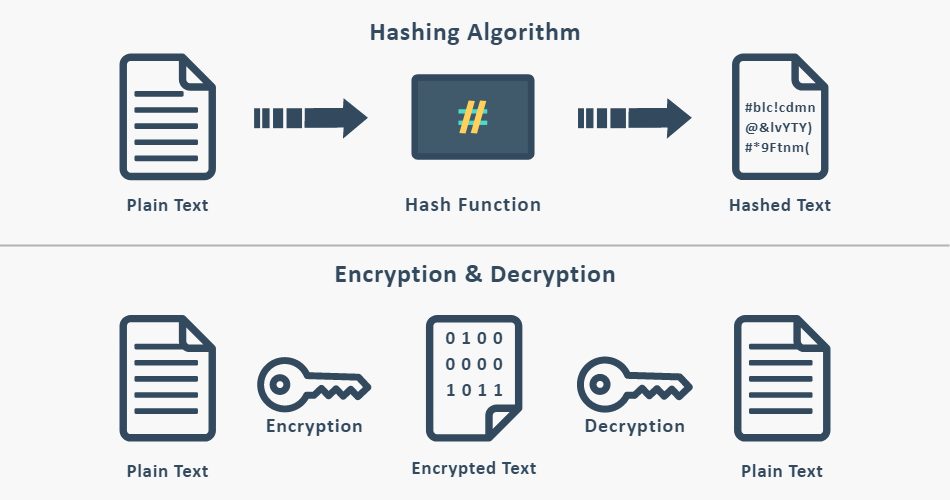

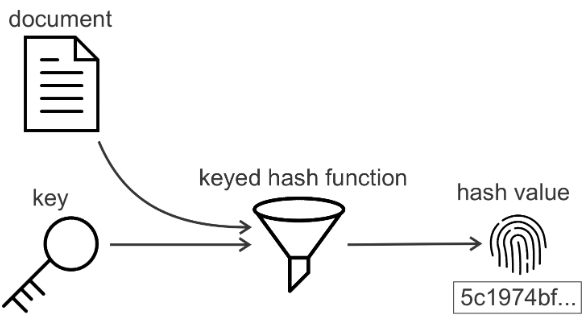

| Hashing                                | Encryption                                                                                                                                                                                                                                                                                                                                                                                         | Description                                                                                                                                                                                                                                                           |
|----------------------------------------|----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Type                                   | Hashing is a one-way function, and it digests a unique message and generates an input file from it or else a string of text. Hashing doesn’t use keys.                                                                                                                                                                                                                                             | Encryption is a two-way function. It changes the data into an unreadable format, which is called ciphertext. And later, using an encryption key, also called the private key, it gets decrypted.                                                                      |
| Function                               | Hashing is similar to checksum, where it uses a hash function on data for mapping it to a fixed size output. It’s helpful to verify the integrity of the file. Also, it’s helpful to compare an entered value with a stored value without reading the content of the file.                                                                                                                         | The message is encrypted in a way that only an authorized person can have access to it. It’s useful to prevent unauthorized users from reading or altering a file by making it into an unreadable format.                                                             |
| Result Value                           | The result is a hashed string of a fixed length.                                                                                                                                                                                                                                                                                                                                                   | The result is an encrypted string of a variable length.                                                                                                                                                                                                               |
| Reason                                 | The main reason for hashing is the verification of data. For example, to protect its integrity.                                                                                                                                                                                                                                                                                                    | The main reason is to transfer data securely during the session. For example, you are protecting data confidentiality.                                                                                                                                                |
| Algorithm Types                        | SHA-1, SHA-2, Tiger, MD5 are some of the prime examples of Hashing algorithms.                                                                                                                                                                                                                                                                                                                     | RSA, AES, and DES algorithms are examples of Encryption.                                                                                                                                                                                                              |
| Output                                 | It can’t be reversed back to the original message. Hashing algorithms are designed in a way that it cannot be retrieved back to its original string from the hash value.                                                                                                                                                                                                                           | The original encrypted message can always be reversed back to its original form using the associated decryption key.                                                                                                                                                  |
| Use Case                               | Hashing is a good option to go with if you’re looking to send a file to someone, but you afraid of chances of being intercept and altered by someone. In this scenario, you can publicly use Hashing and post the hash value publicly to make sure that the recipient stays assured that they’re getting the right file by checking the hash value matches with the publicly available hash value. | Encryption is good to go with if you’re looking to send someone a message. You encrypt that message with a key, so it becomes unreadable and can only be decrypted back to its original form by an authorized person who has the same or different key to decrypt it. |
| Example in Theory (Mathematical Level) | Modulo Division: 22 % 7 = 1 It’s not reversible because no operation can help quotient and divide to reconstitute the divisor or vice versa.                                                                                                                                                                                                                                                       | Addition: 4 + 3 = 7 It’s reversible. For instance, the result can be subtracted with other addends, like: 7 – 3 = 4 One more example, Multiplication: 5 * 3 = 15 Can be reversed back by using the result divided by one of the factors like: 15 / 5 = 3              |

[How to hash with Python using hmac](https://docs.python.org/3/library/hmac.html)

[Data Authentication with Keyed Hashing](https://freecontent.manning.com/data-authentication-with-keyed-hashing/)

In [ ]:
def get_timestamp():
    # time.time() returns the time in seconds since 1970/1/1
    # but Binance wants the miliseconds so I * 1000
    return int(time.time() * 1000)

def hashing(query_string):
    # Hash the query that I want to give to Binance using the Secret Key as a Key, using SHA256 method
    return hmac.new(key=BINANCE_SECRET_KEY.encode("utf-8"), msg=query_string.encode("utf-8"), digestmod=hashlib.sha256).hexdigest()

def dispatch_request(http_method):
    session = requests.Session()
    session.headers.update(
        {
            "Content-Type": "application/json;charset=utf-8",
            "X-MBX-APIKEY": BINANCE_API_KEY,
        }
    )

    return {
        "GET": session.get,
        "DELETE": session.delete,
        "PUT": session.put,
        "POST": session.post,
    }.get(http_method, "GET")


# used for sending request requires the signature
def send_signed_request(http_method, url_path, payload={}):
    query_string = urlencode(payload, True)
    if query_string:
        query_string = f"{query_string}&timestamp={get_timestamp()}"
        print(query_string)
    else:
        query_string = f"timestamp={get_timestamp()}"

    # Notice that in the url is specified:
        # query string so the server can know what to do
        # signature, which is generated using the SECRET_KEY + the query,
        # so the server will calculate on its own the hash, to compare with the one you provided,
        # and if they're the same, then you have just proven that you have the SECRET_KEY
    url = (f'{BINANCE_URL}{url_path}?{query_string}&signature={hashing(query_string)}')
    print(f"{http_method} {url}")
    params = {"url": url, "params": {}}
    response = dispatch_request(http_method)(**params)
    return response.json()


Headers are passed to the server when doing the request

In [ ]:
session = requests.Session()
session.headers

In [ ]:
session.headers.update(
    {
        "Content-Type": "application/json;charset=utf-8",
        "X-MBX-APIKEY": BINANCE_API_KEY,
    }
)

In [ ]:
def binance_place_order(symbol: str, side: str, type: str, quantity: float):
    """Sends order to binance.
    Params
    symbol (str)    Market to trade.    BTCUSDT
    side (str)      Operation.          BUY or SELL
    type (str)      LIMIT               timeInForce, quantity, price
                    MARKET              quantity or quoteOrderQty
                    STOP_LOSS           quantity, stopPrice
                    STOP_LOSS_LIMIT     timeInForce, quantity, price, stopPrice
                    TAKE_PROFIT         quantity, stopPrice
                    TAKE_PROFIT_LIMIT	timeInForce, quantity, price, stopPrice
                    LIMIT_MAKER	        quantity, price

    Return
    response
    """
    # if type == "MARKET":
    #     pass
    params = {
        "symbol": symbol,
        "side": side,
        "type": type,
        "quantity": quantity,
        'recvWindow':6000
    }
    response = send_signed_request("POST", "order", params)
    return response

In [ ]:
# MIN_NOTIONAL = quantity * PRICE
10/0.003

In [ ]:
trade = binance_place_order(symbol='FISBUSD', side='SELL', type='MARKET', quantity=20)
trade

## Check Server Time

[Error “Timestamp for this request is outside of the recvWindow”](https://dev.binance.vision/t/error-timestamp-for-this-request-is-outside-of-the-recvwindow/1357)

You may check if there is some difference between your time and the server

in order to know if you need to increase recvWindow parameters, as it is by default 5000ms

In [ ]:
url = f'{BINANCE_URL}exchangeInfo'
before = time.time()
r = requests.get(url)
after = time.time()

serverTime = r.json()['serverTime']

before = int(before*1000)
after = int(after*1000)

import pandas as pd
print(pd.Series([before, serverTime, after]).plot())

## Bonus: let's create a mini-blockchain

In [ ]:
def do_hashes(key, value):
    # Hash the query that I want to give to Binance using the Secret Key as a Key, using SHA256 method
    return hmac.new(key=str(key).encode("utf-8"), msg=value.encode("utf-8"), digestmod=hashlib.sha256).hexdigest()

In [ ]:
i = 0
while True:
    a = do_hashes(i, 'test')
    if a.startswith('aaaaa'):
        break
    i += 1
print(a, i)

In [ ]:
j = 0
while True:
    b = do_hashes(j, a)
    if b.startswith('aaaaa'):
        break
    j += 1
print(b, j)

In [ ]:
do_hashes(j, a)

In [ ]:
class Block():
    def __init__(self, previous_value) -> None:
        self.previous_value = previous_value
    
    def mine(self):
        i = 0
        while True:
            a = do_hashes(i, self.previous_value)
            if a.startswith('aaaaa'):
                break
            i += 1
        self.key = i
        self.value = a

In [ ]:
block1 = Block('a')
block1.mine()

In [ ]:
block1.key
block1.value

In [ ]:
block2 = Block(block1.value)
block2.mine()

In [ ]:
block2.key
block2.value